In [ ]:
# 1. 라이브러리 import
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # 선형회귀 모델
from sklearn.metrics import mean_absolute_error # 0.1 기준 점수가 낮으면 좋음
from sklearn.metrics import r2_score # mean_absolute_error을 검사하는 함수

In [3]:
# 2. 데이터 로드 - 캘리포니아 주택 데이터셋

housing = fetch_california_housing(as_frame=True)

# DataFrame으로 변환
df = housing.frame

print(df.head())

# MedInc     평균 소득
# HouseAge   집 나이
# AveRooms   평균 방 개수
# MedHouseVal → 집 가격(예측 대상)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
# 3. 데이터 기술통계 확인
# 결측치 있는가?
# 숫자 범위는?

print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

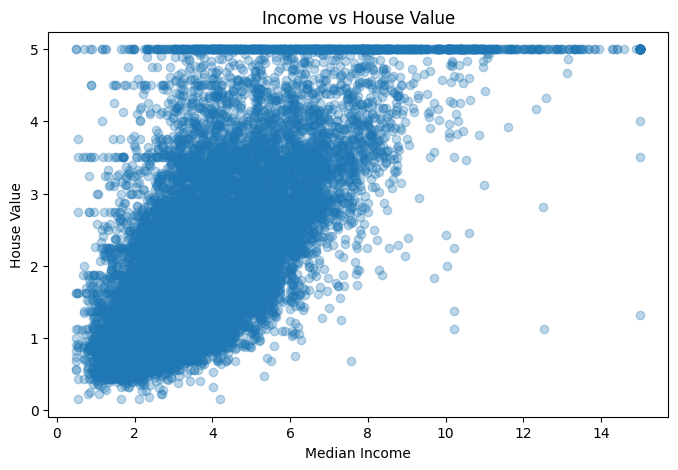

In [ ]:
# 4. 시각화
plt.figure(figsize=(8,5))

# x -> y 를 판단, x가 시계열이 아니라 산점도로 분석
plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("House Value")

plt.title("Income vs House Value")

plt.show()
# 점들의 분포가 우상향(↗) : 소득이 높을수록 집값이 비싼 경향

In [6]:
# 5. X, Y 분리
# 1) 독립 변수(특성) 데이터셋 생성
# 전체 데이터프레임(df)에서 예측하고자 하는 정답 레이블인 "MedHouseVal" 열(column)만 제외하고 
# 나머지 모든 열을 추출하여 변수 X에 저장합니다. (axis=1은 '열'을 기준으로 삭제하겠다는 의미)
X = df.drop("MedHouseVal", axis=1)

# 2) 종속 변수(타겟/정답) 데이터셋 생성
# 전체 데이터프레임(df)에서 예측 목표인 "MedHouseVal"(주택 가격 중앙값) 열만 선택하여 
# 변수 Y에 저장합니다.
Y = df["MedHouseVal"]

In [7]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [8]:
Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [9]:
# 6. 학습용 / 테스트용 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [10]:
# 7. 모델 생성 - 가장 쉬운 모델 하나만 테스트
model = LinearRegression()
model.fit(X_train,y_train)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LinearRegression()

In [11]:
# 8. 예측
pred = model.predict(X_test)
pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [12]:
# 9. 평가
# MAE (Mean Absolute Error) 예측이 평균적으로 얼마나 틀렸는지를 나타냅니다. 
# R² (결정계수, R-squared) 모델이 데이터를 얼마나 잘 설명하는지를 나타냅니다.

mae = mean_absolute_error(y_test,pred)
print("MAE:", mae) # 평균적으로 mae정도 틀림

r2 = r2_score(y_test,pred)
print("R2:", r2) # 1.0 = 완벽 ~ 0.0 = 랜덤 수준 : 0.5이상이면 좋음

MAE: 0.5332001304956555
R2: 0.575787706032451
